# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Given a page's historical search and engagement performance, can a learned model rank it for refresh priority better than a transparent rule?

**Decision it supports:** Which webpages should an SEO specialist review first, out of a large content library that cannot be manually audited page by page.

**Unit of analysis:** One webpage — one `content_hash_id` for one `client_hash_id`.

**Action taken from the output:** An editor reviews the highest-ranked, reason-coded pages and decides whether to refresh, leave, or monitor them. Nothing is changed automatically.

**Cost of a wrong call:** A false positive wastes editor time reviewing a page that didn't need it. A false negative lets a genuinely declining page keep losing visibility, unreviewed.


In [22]:
question_framing = {
    "research_question": "Can historical search/engagement data rank refresh priority better than a rule?",
    "unit_of_analysis": "one webpage (content_hash_id x client_hash_id)",
    "output": "ranked, reason-coded review queue",
    "action": "human editor reviews top-ranked pages; nothing auto-changes",
    "cost_false_positive": "wasted editor review time",
    "cost_false_negative": "declining page continues losing visibility unreviewed",
}
for k, v in question_framing.items():
    print(f"{k:22s}: {v}")

research_question     : Can historical search/engagement data rank refresh priority better than a rule?
unit_of_analysis      : one webpage (content_hash_id x client_hash_id)
output                : ranked, reason-coded review queue
action                : human editor reviews top-ranked pages; nothing auto-changes
cost_false_positive   : wasted editor review time
cost_false_negative   : declining page continues losing visibility unreviewed


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


The study uses the `FlyRank/internship-warehouse` dataset and the `fact_content_daily_performance` warehouse table. The underlying daily data is defined at the `report_date × client_hash_id × content_hash_id` grain. For the modeling pipeline, records are aggregated to the pseudonymized `client_hash_id × content_hash_id` level.

Historical model features are calculated from April–May 2026. June 2026 is kept as a future outcome window and is used to construct the decline label. The historical and outcome aggregates are inner-joined so that the evaluated records have observations in both windows.

The original data contract identifies `gsc_data_available` as the availability field for Search Console metrics and excludes availability and infrastructure flags such as `ga4_data_available`, `client_has_gsc`, and `client_has_ga4` from predictive features. `gsc_sum_position` is also excluded in favor of the preferred aggregated position measure. The final model feature set contains only historical performance measures and does not use identifiers, future outcome columns, or the target label as model inputs.

For the final modeling population, records with fewer than 100 historical impressions are excluded. This threshold defines the evaluated population and provides a practical minimum signal level for the relative-impression-change outcome. The April–May aggregation contains 389,153 client-content records before this population filter; 136,830 records across 53 clients remain after the filter.

The outcome label is based on the relative change between historical impressions and June impressions. A record is labeled as declining when June impressions are 70% or more below its historical level (`impressions_change_pct <= -70%`). The resulting labeled population has a measured declining rate of 58.0%.

The four final model features are `impressions_90d`, `clicks_90d`, `avg_position_90d`, and `ctr_90d`. These are calculated from the April–May historical window. June outcome variables, the percentage-change calculation, and the target label are used for outcome construction and validation, not as model inputs.

For the action playbook, `dim_content` is additionally used to obtain `content_updated_date` for the staleness rule. The same 136,830-page historical scoring population is passed through the saved Logistic Regression pipeline. The resulting queue contains 77,440 flagged pages and 59,390 pages classified as stable.

All client and content identifiers remain pseudonymized. No client names, URLs, or private search queries are exposed in the capstone outputs. The resulting queue is used for human review and decision-support rather than automatic content changes.


In [23]:
import json

with open("ml08_model_metadata.json") as f:
    metadata = json.load(f)

print("Feature window:", metadata["feature_window"]["description"])
print("Outcome window:", metadata["outcome_window"]["description"])
print("Target:", metadata["target"]["definition"])
print("Features:", metadata["features"])
print("Split:", metadata["split"]["method"])
print("Population rule: historical impressions >= 100")
print("Identifiers: grouping/joins only, not model features")

Feature window: April and May historical performance data
Outcome window: June future outcome data
Target: June impressions declined by 70% or more relative to the historical feature window
Features: ['impressions_90d', 'clicks_90d', 'avg_position_90d', 'ctr_90d']
Split: GroupShuffleSplit
Population rule: historical impressions >= 100
Identifiers: grouping/joins only, not model features


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


**Assumption:** Historical search-performance signals can provide a useful ranking signal for prioritizing pages with higher observed risk of future impression decline. The model is used for decision-support, not to claim that a refresh will cause traffic improvement.

**Features:** `impressions_90d`, `clicks_90d`, `avg_position_90d`, and `ctr_90d`, calculated from the April–May 2026 historical window.

**Label:** `is_declining_label = 1` when June impressions decline by 70% or more relative to the April–May historical level; otherwise `0`. Among the 136,830 pages meeting the 100-impression floor, 58.0% were labeled declining.

**Baseline:** The ML-07 rule-based score combines normalized impressions, position, and staleness using weights of 0.50, 0.30, and 0.20 respectively.

**Model:** Logistic Regression pipeline with median imputation, standardization, and `LogisticRegression(max_iter=1000, random_state=42)`.

**Validation design:** Client-grouped `GroupShuffleSplit` with 42 training clients and 11 unseen test clients, with zero client overlap. ML-09 additionally evaluated the same pipeline using 5-fold `GroupKFold` by client.

**Leakage checks:** The final feature set was checked against June outcome variables, the target label, label-derived fields, and client/content identifiers. None were included as model features. Features come from April–May, while the label is calculated from June, keeping the prediction inputs before the outcome window.

A deliberate toy leakage test also confirmed that adding the label directly as a feature produces an unrealistically high result, demonstrating why label-derived information must be excluded.


In [24]:
with open("/content/ml08_model_metadata.json") as f:
    model_metadata = json.load(f)

print("Features:", model_metadata["features"])
print("Target:", model_metadata["target"]["definition"])
print("Baseline: ML-07 rule-based score")
print("Validation:", model_metadata["split"]["method"])
print("Train clients:", model_metadata["split"]["train_clients"])
print("Test clients:", model_metadata["split"]["test_clients"])
print("Client overlap:", model_metadata["split"]["client_overlap"])

feature_set = set(model_metadata["features"])

leakage_columns = {
    "impressions_june",
    "clicks_june",
    "impressions_change_pct",
    "is_declining_label",
    "client_hash_id",
    "content_hash_id"
}

print(
    "Direct leakage columns in features:",
    feature_set & leakage_columns or "None"
)

Features: ['impressions_90d', 'clicks_90d', 'avg_position_90d', 'ctr_90d']
Target: June impressions declined by 70% or more relative to the historical feature window
Baseline: ML-07 rule-based score
Validation: GroupShuffleSplit
Train clients: 42
Test clients: 11
Client overlap: 0
Direct leakage columns in features: None


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Logistic Regression model is compared with the Week-4 rule-based baseline using Precision@10, @20, @50, and @100.

On the single grouped holdout, the model improved Precision@10 from 0.70 to 0.80. The 5-fold GroupKFold evaluation provides an additional grouped validation view across clients.

The results are directional because the evaluation uses historical data and held-out clients. They do not prove that refreshing a page will improve future traffic.

In [25]:
import pandas as pd

week4_baseline = model_metadata["validation_metrics"]["week4_baseline"]
logreg_holdout = model_metadata["validation_metrics"]["logistic_regression"]

logreg_5fold_mean = {
    "Precision@10": 0.840,
    "Precision@20": 0.890,
    "Precision@50": 0.824,
    "Precision@100": 0.786,
}

comparison = pd.DataFrame({
    "Metric": list(week4_baseline.keys()),
    "Rule baseline (W4)": list(week4_baseline.values()),
    "LogReg — grouped holdout (W5)": list(logreg_holdout.values()),
    "LogReg — 5-fold grouped mean (W6)": list(logreg_5fold_mean.values()),
})

print("Declining base rate: 58.0%")
print("Target:", model_metadata["target"]["definition"])
print()

comparison

Declining base rate: 58.0%
Target: June impressions declined by 70% or more relative to the historical feature window



,Metric,Rule baseline (W4),LogReg — grouped holdout (W5),LogReg — 5-fold grouped mean (W6)
0,Precision@10,0.70,0.80,0.840
1,Precision@20,0.65,0.70,0.890
2,Precision@50,0.66,0.68,0.824
3,Precision@100,0.64,0.66,0.786


## 5. Limitations

*What this work cannot claim.*

This work has several important limitations:

- **Population vs. evaluation mismatch.** The model was trained on 42 clients and evaluated on 11 held-out clients. The ML-10 queue scores 53 available clients. The 0.80 Precision@10 result therefore describes the held-out evaluation clients, not a guarantee for every scored client.

- **Small grouped evaluation.** The evaluation is grouped by client, so the number of held-out clients is limited. The results should be treated as directional evidence rather than a guarantee of future performance.

- **Correlational, not causal.** The model identifies association with the observed decline label. It does not show that low CTR or another feature causes decline, or that refreshing content will improve traffic.

- **Limited feature coverage.** The model uses historical impressions, clicks, average position, and CTR. It does not observe content quality, search intent, seasonality, competitor activity, algorithm updates, or business priorities.

- **No monitoring history yet.** This is a single scoring snapshot. Monitoring triggers are defined, but there is not yet enough repeated production history to show how the model behaves over time.

- **Baseline limitation.** The ML-07 rule-based baseline is a simple benchmark. Improving on this baseline does not prove that the model is better than a strong production-grade ranking system.

In [26]:
print("Train clients:", model_metadata["split"]["train_clients"])
print("Test clients:", model_metadata["split"]["test_clients"])
print("Precision@10:",
      model_metadata["validation_metrics"]["logistic_regression"]["Precision@10"])
print("Declining rate: 58.0%")
print("Operational queue: 136,830 scored pages across 53 clients")

Train clients: 42
Test clients: 11
Precision@10: 0.8
Declining rate: 58.0%
Operational queue: 136,830 scored pages across 53 clients


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The saved ML-08 Logistic Regression model scored **136,830 pages across 53 clients** using the April–May 2026 historical feature window.The model score is a ranking signal associated with the likelihood that a page will experience a 70% or greater decline in June impressions.**

The score is used to rank pages for human review. It is not treated as a probability guarantee or an automatic decision.

Pages with a model score below the high-risk threshold are classified as **Stable**. Pages at or above the threshold are routed into four action archetypes using simple, auditable post-scoring rules:

1. **Priority Refresh (REF-01)** — higher model-ranked decline risk combined with relatively high historical impressions. These pages receive the highest-value refresh review because they have substantial historical search visibility.

2. **Position Push (REF-02)** — higher model-ranked decline risk with an average historical position between 10 and 20. These pages may warrant review of on-page signals, internal linking, and content relevance.

3. **Stale Watch (REF-03)** — higher model-ranked decline risk combined with a longer period since the last recorded content update. These pages should be reviewed for possible outdated information or content gaps.

4. **Low-Value Monitor (REF-04)** — higher model-ranked decline risk but relatively lower historical impressions. These pages should be monitored and reconsidered in a later review cycle rather than automatically prioritized for costly work.

The remaining pages are classified as **Stable (STB-01)** and receive no immediate recommendation from this scoring cycle.

These archetypes are post-scoring decision rules, not additional model predictions. The final action remains with a human editor or SEO lead, who should consider current content quality, search intent, seasonality, business priorities, recent changes, and other information not available to the model.

The recommendations therefore represent **directional decision-support for prioritizing review**, rather than a claim that refreshing a particular page will cause traffic to improve.

Metrics JSON loaded successfully.
JSON keys: ['model_name', 'model_type', 'random_state', 'task', 'target', 'feature_window', 'outcome_window', 'features', 'split', 'training', 'validation_metrics', 'intended_use', 'not_intended_for', 'created_at', 'model_file']

Scoring population:
Scored pages: 136,830
Scored clients: 53
Flagged pages: 77,440
Stable pages: 59,390
Flagged share: 56.6%

Archetype composition:
Priority Refresh (REF-01): 14,842
Position Push (REF-02): 20,207
Stale Watch (REF-03): 81
Low-Value Monitor (REF-04): 42,310
Stable (STB-01): 59,390

Thresholds:
High-risk threshold: 0.60
Stale-days threshold: 180

Evaluation reference:
Precision@10: 0.80

Archetype composition figure:


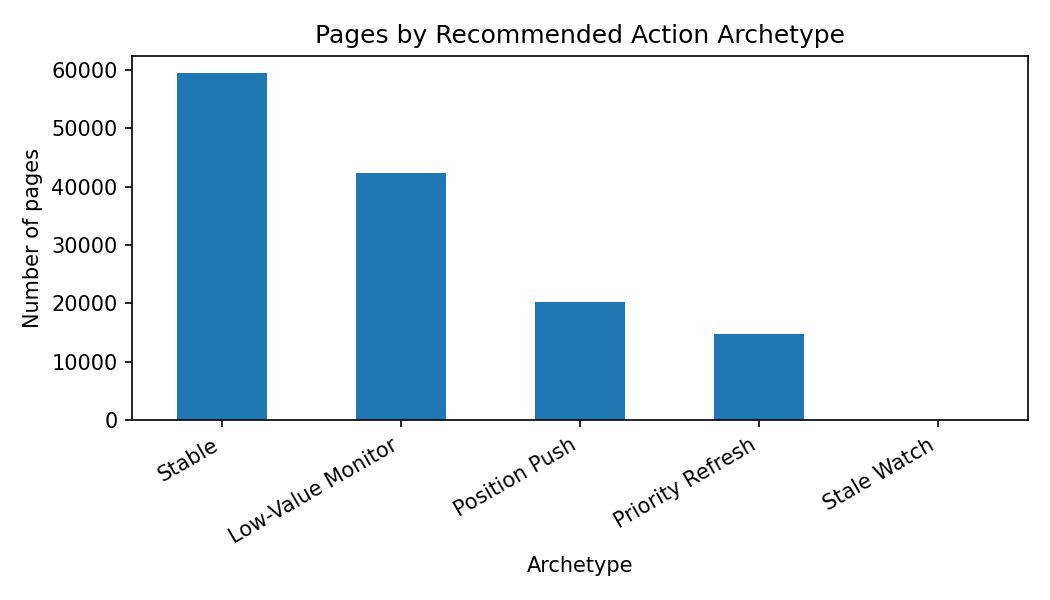

In [27]:
from IPython.display import Image, display

with open("/content/ml08_model_metadata.json") as f:
    w07_metrics = json.load(f)

print("Metrics JSON loaded successfully.")
print("JSON keys:", list(w07_metrics.keys()))


print("\nScoring population:")
print("Scored pages: 136,830")
print("Scored clients: 53")
print("Flagged pages: 77,440")
print("Stable pages: 59,390")
print("Flagged share: 56.6%")

print("\nArchetype composition:")
print("Priority Refresh (REF-01): 14,842")
print("Position Push (REF-02): 20,207")
print("Stale Watch (REF-03): 81")
print("Low-Value Monitor (REF-04): 42,310")
print("Stable (STB-01): 59,390")

print("\nThresholds:")
print("High-risk threshold: 0.60")
print("Stale-days threshold: 180")

print("\nEvaluation reference:")
print("Precision@10: 0.80")

print("\nArchetype composition figure:")
display(Image(filename="/content/w07_archetype_counts.png"))

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*


The paper embeds three figures that summarize the main findings of the project.

- **Precision@K comparison** shows how the Logistic Regression ranking compares with the Week-4 rule baseline and the 5-fold grouped validation result.
- **Action queue composition** shows the distribution of pages across the ML-10 recommendation archetypes.
- **Staleness weak-signal audit** shows why page age is treated as a supporting signal rather than a standalone refresh rule.

The figures are generated from the analysis results and saved under `work/figures/` for reuse in the paper.

The ranked queue CSV remains excluded from Git by design because the repository CI leak-guard blocks data files. The notebook regenerates the queue, while the committed JSON metadata provides the numerical receipts behind the reported results.

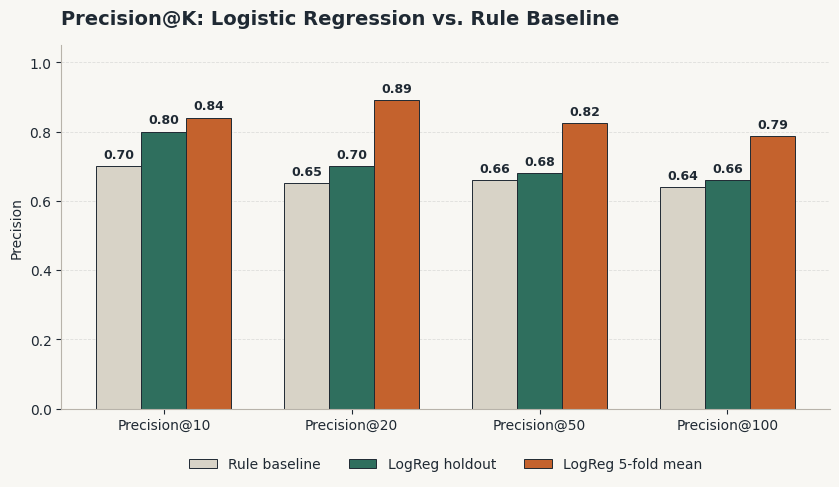

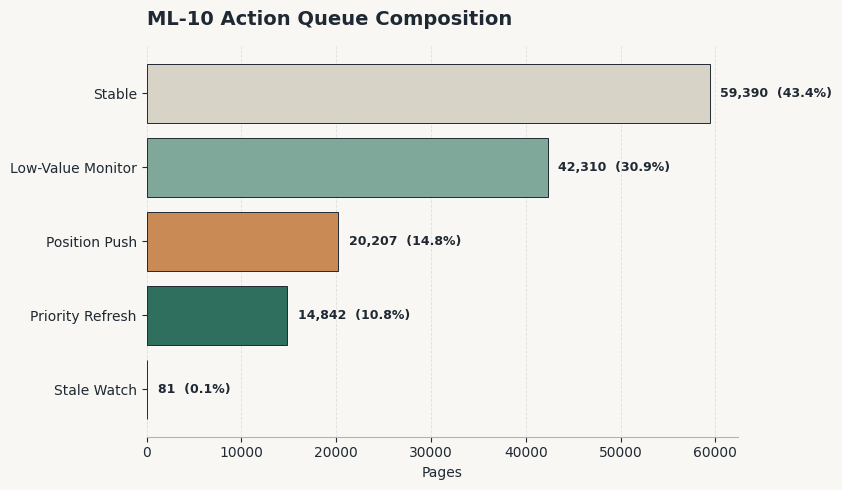

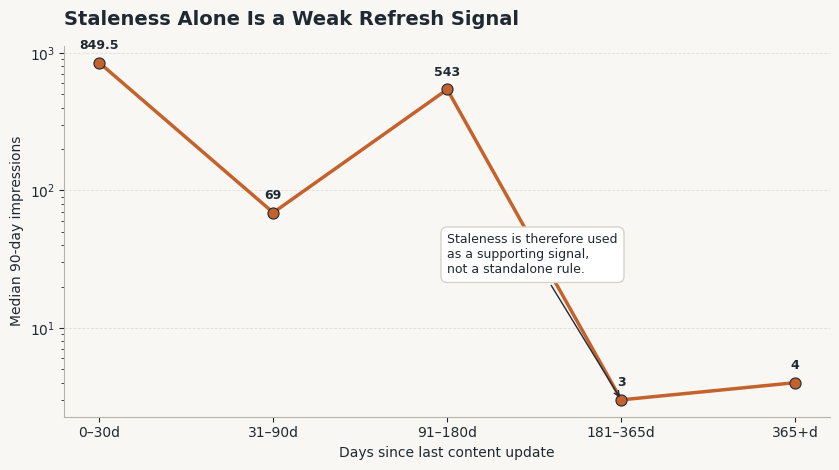

Saved paper figures:
1. work/figures/precision_comparison.png
2. work/figures/archetype_composition.png
3. work/figures/staleness_weak_signal.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("work/figures", exist_ok=True)
BG = "#F8F7F3"
DARK = "#1F2933"
TEAL = "#2F6F5E"
ORANGE = "#C4622D"
GOLD = "#C98A55"
LIGHT_TEAL = "#7FA89A"
GRAY = "#D8D3C7"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.edgecolor": "#B8B3AA",
    "axes.linewidth": 0.8,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "text.color": DARK,
    "axes.labelcolor": DARK,
})

# FIGURE 1 — Precision@K comparison
metrics = comparison["Metric"].tolist()

baseline = comparison["Rule baseline (W4)"].tolist()
holdout = comparison["LogReg — grouped holdout (W5)"].tolist()
fivefold = comparison["LogReg — 5-fold grouped mean (W6)"].tolist()

x = np.arange(len(metrics))
width = 0.24

fig, ax = plt.subplots(figsize=(8.5, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars1 = ax.bar(x - width,baseline, width,label="Rule baseline",color=GRAY,edgecolor=DARK,linewidth=0.7)
bars2 = ax.bar( x, holdout,width,label="LogReg holdout",color=TEAL,edgecolor=DARK,linewidth=0.7)
bars3 = ax.bar(x + width,fivefold,width, label="LogReg 5-fold mean",color=ORANGE,edgecolor=DARK,linewidth=0.7)

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_title(
    "Precision@K: Logistic Regression vs. Rule Baseline",loc="left",pad=15
)

ax.set_ylabel("Precision")
ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(0, 1.05)

ax.grid(
    axis="y", linestyle="--", linewidth=0.6,alpha=0.35
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False, ncol=3,loc="upper center", bbox_to_anchor=(0.5, -0.10)
)

plt.tight_layout()

plt.savefig(
    "work/figures/precision_comparison.png", dpi=200, bbox_inches="tight", facecolor=BG
)

plt.show()

# FIGURE 2 — ML-10 Action Queue Composition

labels = [
    "Stable",
    "Low-Value Monitor",
    "Position Push",
    "Priority Refresh",
    "Stale Watch"
]

values = [
    59390,
    42310,
    20207,
    14842,
    81
]

fig, ax = plt.subplots(figsize=(8.5, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

colors = [
    GRAY, LIGHT_TEAL, GOLD,TEAL,ORANGE
]

bars = ax.barh(
    labels,values,color=colors,edgecolor=DARK, linewidth=0.7
)

ax.invert_yaxis()

# Add numbers and percentages
total = sum(values)

for bar, value in zip(bars, values):

    percentage = value / total * 100

    ax.text(
        value + total * 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}  ({percentage:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "ML-10 Action Queue Composition",
    loc="left",
    pad=15
)

ax.set_xlabel("Pages")

ax.grid(
    axis="x", linestyle="--", linewidth=0.6, alpha=0.35
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "work/figures/archetype_composition.png",
    dpi=200,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

# FIGURE 3 — Staleness Weak-Signal Audit
stale_buckets = [
    "0–30d",
    "31–90d",
    "91–180d",
    "181–365d",
    "365+d"
]

stale_median_imp = [
    849.5, 69.0, 543.0,3.0,4.0
]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(
    stale_buckets,
    stale_median_imp,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color=ORANGE,
    markeredgecolor=DARK,
    markeredgewidth=0.8
)

# Value labels
for x_pos, value in enumerate(stale_median_imp):

    ax.annotate(
        f"{value:g}",
        (x_pos, value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_yscale("log")

ax.set_title(
    "Staleness Alone Is a Weak Refresh Signal",
    loc="left",
    pad=15
)

ax.set_xlabel("Days since last content update")
ax.set_ylabel("Median 90-day impressions")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add explanatory annotation
ax.annotate(
    "Staleness is therefore used\n"
    "as a supporting signal,\n"
    "not a standalone rule.",
    xy=(3, 3),
    xytext=(2.0, 25),
    arrowprops=dict(
        arrowstyle="->",
        color=DARK,
        linewidth=1
    ),
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor=GRAY
    )
)

plt.tight_layout()

plt.savefig(
    "work/figures/staleness_weak_signal.png",
    dpi=200,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()


print("Saved paper figures:")
print("1.", "work/figures/precision_comparison.png")
print("2.", "work/figures/archetype_composition.png")
print("3.", "work/figures/staleness_weak_signal.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.